<a href="https://colab.research.google.com/github/nataprofits/IBM_test_repo/blob/test-from-colab/Building_Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install tensorflow


In [3]:
import numpy as np
from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

11490434/11490434 [==============================] - 0s 0us/step


In [4]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input

input_layer = Input(shape=(784,))
encoded = Dense(64, activation='relu')(input_layer)

bottleneck = Dense(32, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(bottleneck)
output_layer = Dense(784, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, output_layer)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 784)]             0         
                                                                 
 dense (Dense)               (None, 64)                50240     
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 64)                2112      
                                                                 
 dense_3 (Dense)             (None, 784)               50960     
                                                                 
Total params: 105392 (411.69 KB)
Trainable params: 105392 (411.69 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [5]:
autoencoder.fit(
    x_train, x_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
    )

Epoch 1/50
235/235 [==============================] - 4s 14ms/step - loss: 0.2597 - val_loss: 0.1773
Epoch 2/50
235/235 [==============================] - 3s 11ms/step - loss: 0.1637 - val_loss: 0.1499
Epoch 3/50
235/235 [==============================] - 3s 11ms/step - loss: 0.1428 - val_loss: 0.1334
Epoch 4/50
235/235 [==============================] - 3s 11ms/step - loss: 0.1292 - val_loss: 0.1230
Epoch 5/50
235/235 [==============================] - 3s 11ms/step - loss: 0.1221 - val_loss: 0.1181
Epoch 6/50
235/235 [==============================] - 3s 11ms/step - loss: 0.1178 - val_loss: 0.1138
Epoch 7/50
235/235 [==============================] - 3s 11ms/step - loss: 0.1137 - val_loss: 0.1109
Epoch 8/50
235/235 [==============================] - 3s 11ms/step - loss: 0.1109 - val_loss: 0.1090
Epoch 9/50
235/235 [==============================] - 3s 11ms/step - loss: 0.1090 - val_loss: 0.1073
Epoch 10/50
235/235 [==============================] - 3s 11ms/step - loss: 0.1076 - val_lo

In [6]:
!pip install matplotlib

313/313 [==============================] - 1s 2ms/step


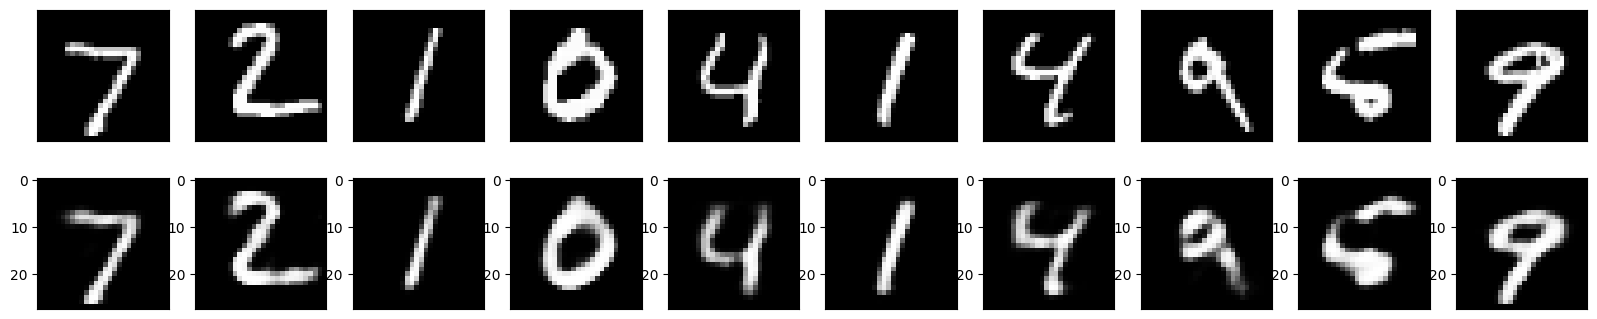

In [7]:
import matplotlib.pyplot as plt

reconstructed = autoencoder.predict(x_test)

n=10
plt.figure(figsize=(20,4))

for i in range(n):
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(reconstructed[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
plt.show()


In [8]:
for layer in autoencoder.layers[-4:]:
    layer.trainable = True

# Compile the model again
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the model again
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))


Epoch 1/10
235/235 [==============================] - 4s 13ms/step - loss: 0.0922 - val_loss: 0.0910
Epoch 2/10
235/235 [==============================] - 3s 11ms/step - loss: 0.0918 - val_loss: 0.0910
Epoch 3/10
235/235 [==============================] - 3s 11ms/step - loss: 0.0918 - val_loss: 0.0909
Epoch 4/10
235/235 [==============================] - 3s 11ms/step - loss: 0.0918 - val_loss: 0.0911
Epoch 5/10
235/235 [==============================] - 3s 11ms/step - loss: 0.0917 - val_loss: 0.0908
Epoch 6/10
235/235 [==============================] - 3s 11ms/step - loss: 0.0916 - val_loss: 0.0908
Epoch 7/10
235/235 [==============================] - 3s 11ms/step - loss: 0.0916 - val_loss: 0.0906
Epoch 8/10
235/235 [==============================] - 3s 11ms/step - loss: 0.0915 - val_loss: 0.0906
Epoch 9/10
235/235 [==============================] - 3s 11ms/step - loss: 0.0914 - val_loss: 0.0905
Epoch 10/10
235/235 [==============================] - 3s 12ms/step - loss: 0.0914 - val_lo

Epoch 1/20
118/118 [==============================] - 3s 26ms/step - loss: 0.1844 - val_loss: 0.1535
Epoch 2/20
118/118 [==============================] - 3s 25ms/step - loss: 0.1473 - val_loss: 0.1408
Epoch 3/20
118/118 [==============================] - 3s 24ms/step - loss: 0.1383 - val_loss: 0.1347
Epoch 4/20
118/118 [==============================] - 3s 25ms/step - loss: 0.1337 - val_loss: 0.1313
Epoch 5/20
118/118 [==============================] - 3s 25ms/step - loss: 0.1308 - val_loss: 0.1290
Epoch 6/20
118/118 [==============================] - 3s 25ms/step - loss: 0.1290 - val_loss: 0.1275
Epoch 7/20
118/118 [==============================] - 3s 25ms/step - loss: 0.1276 - val_loss: 0.1264
Epoch 8/20
118/118 [==============================] - 3s 25ms/step - loss: 0.1266 - val_loss: 0.1256
Epoch 9/20
118/118 [==============================] - 3s 24ms/step - loss: 0.1258 - val_loss: 0.1250
Epoch 10/20
118/118 [==============================] - 3s 25ms/step - loss: 0.1251 - val_lo

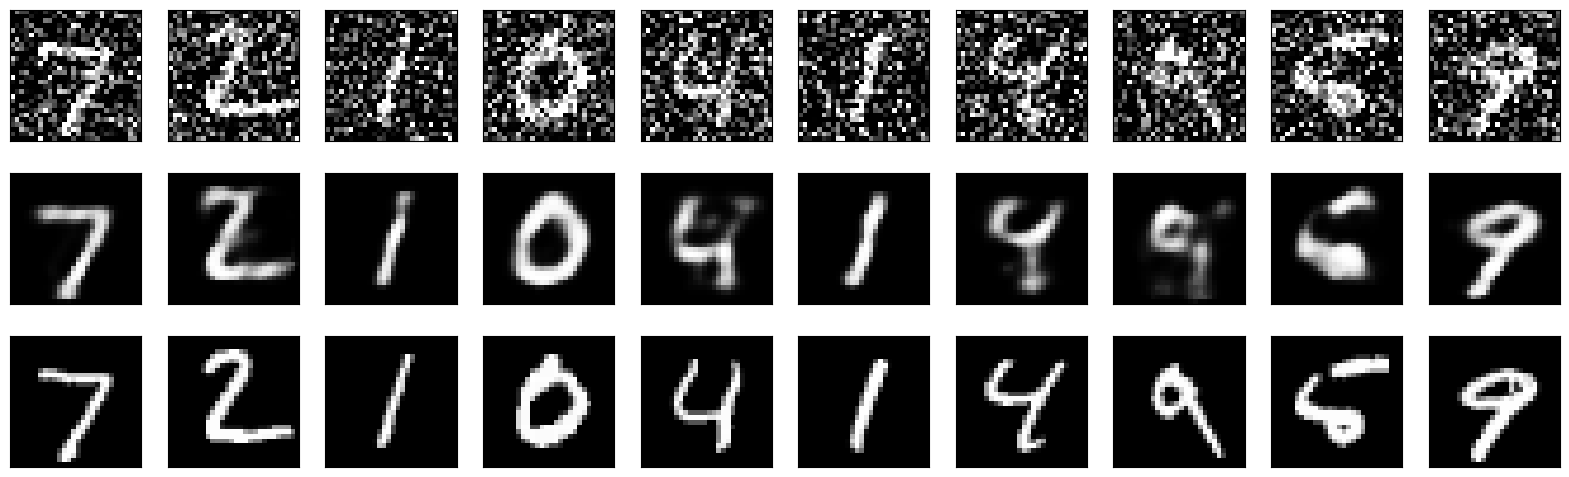

In [9]:
import numpy as np
import matplotlib.pyplot as plt

noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

autoencoder.fit(x_train_noisy, x_train,
                epochs=20,
                batch_size=512,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

reconstructed_noisy = autoencoder.predict(x_test_noisy)

n=10
plt.figure(figsize=(20,6))
for i in range(n):
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(reconstructed_noisy[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(x_test[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [10]:
def create_autoencoder(input_shape, bottleneck_size):
    # Encoder
    input_img = Input(shape=(input_shape,))
    encoded = Dense(128, activation='relu')(input_img)
    encoded = Dense(64, activation='relu')(encoded)
    bottleneck = Dense(bottleneck_size, activation='relu')(encoded)

    # Decoder
    decoded = Dense(64, activation='relu')(bottleneck)
    decoded = Dense(128, activation='relu')(decoded)
    output_img = Dense(input_shape, activation='sigmoid')(decoded)

    # Autoencoder
    autoencoder = Model(input_img, output_img)

    return autoencoder

In [11]:
# Load MNIST data and preprocess
from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

x_train = x_train.reshape((len(x_train), -1))
x_test = x_test.reshape((len(x_test), -1))

# Define bottleneck sizes
bottleneck_sizes = [16, 32, 64]
models = {}
histories = {}

for size in bottleneck_sizes:
    print(f"\nTraining model with bottleneck size: {size}")

    # Create model
    autoencoder = create_autoencoder(input_shape=x_train.shape[1], bottleneck_size=size)
    autoencoder.compile(optimizer='adam', loss='mse')

    # Train model
    history = autoencoder.fit(
        x_train, x_train,
        epochs=50,
        batch_size=256,
        validation_data=(x_test, x_test),
        verbose=1
    )

    # Save model and history
    models[size] = autoencoder
    histories[size] = history



Training model with bottleneck size: 16
Epoch 1/50
235/235 [==============================] - 4s 15ms/step - loss: 0.0654 - val_loss: 0.0382
Epoch 2/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0329 - val_loss: 0.0284
Epoch 3/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0269 - val_loss: 0.0250
Epoch 4/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0243 - val_loss: 0.0232
Epoch 5/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0231 - val_loss: 0.0223
Epoch 6/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0223 - val_loss: 0.0215
Epoch 7/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0217 - val_loss: 0.0210
Epoch 8/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0211 - val_loss: 0.0205
Epoch 9/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0206 - val_loss: 0.0201
Epoch 10/50
235/235 [=============================

Evaluating model with bottleneck size: 16
Test loss (MSE): 0.014705256558954716
Evaluating model with bottleneck size: 32
Test loss (MSE): 0.008445413783192635
Evaluating model with bottleneck size: 64
Test loss (MSE): 0.006238465663045645


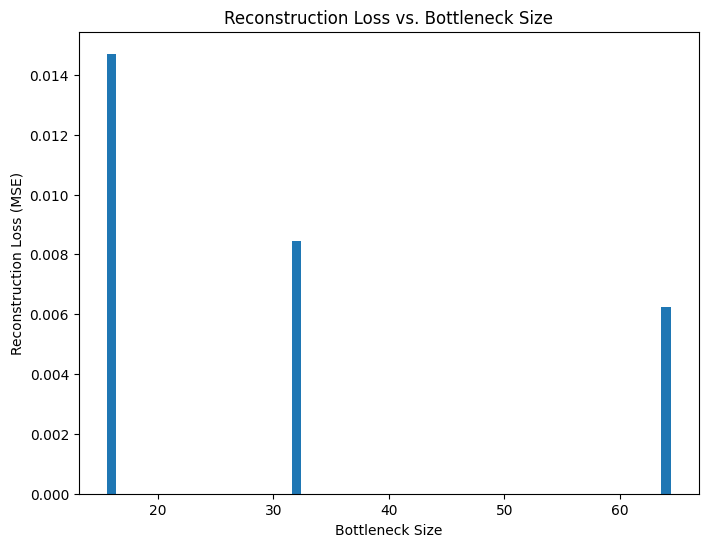

In [12]:
import matplotlib.pyplot as plt

# Evaluate models
test_losses = {}

for size in bottleneck_sizes:
    print(f"Evaluating model with bottleneck size: {size}")
    loss = models[size].evaluate(x_test, x_test, verbose=0)
    test_losses[size] = loss
    print(f"Test loss (MSE): {loss}")

# Compare reconstruction losses
plt.figure(figsize=(8, 6))
plt.bar(test_losses.keys(), test_losses.values())
plt.xlabel('Bottleneck Size')
plt.ylabel('Reconstruction Loss (MSE)')
plt.title('Reconstruction Loss vs. Bottleneck Size')
plt.show()


In [13]:
def create_regularized_autoencoder(input_shape, bottleneck_size, l2_lambda):
    # Encoder with L2 regularization
    input_img = Input(shape=(input_shape,))
    encoded = Dense(128, activation='relu', kernel_regularizer=l2(l2_lambda))(input_img)
    encoded = Dense(64, activation='relu', kernel_regularizer=l2(l2_lambda))(encoded)
    bottleneck = Dense(bottleneck_size, activation='relu', kernel_regularizer=l2(l2_lambda))(encoded)

    # Decoder with L2 regularization
    decoded = Dense(64, activation='relu', kernel_regularizer=l2(l2_lambda))(bottleneck)
    decoded = Dense(128, activation='relu', kernel_regularizer=l2(l2_lambda))(decoded)
    output_img = Dense(input_shape, activation='sigmoid', kernel_regularizer=l2(l2_lambda))(decoded)

    # Autoencoder
    autoencoder = Model(input_img, output_img)
    return autoencoder

In [14]:
from tensorflow.keras.datasets import mnist

# Load MNIST data
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize and reshape
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255
x_train = x_train.reshape((len(x_train), -1))  # Flatten to (60000, 784)
x_test = x_test.reshape((len(x_test), -1))    # Flatten to (10000, 784)

In [16]:
from tensorflow.keras.regularizers import l2
# Non-regularized autoencoder
non_regularized_model = create_regularized_autoencoder(input_shape=784, bottleneck_size=32, l2_lambda=0.0)
non_regularized_model.compile(optimizer='adam', loss='mse')

print("\nTraining Non-Regularized Autoencoder:")
non_regularized_model.fit(
    x_train, x_train,
    epochs=50,
    batch_size=256,
    validation_data=(x_test, x_test),
    verbose=1
)

# Regularized autoencoder
regularized_model = create_regularized_autoencoder(input_shape=784, bottleneck_size=32, l2_lambda=0.001)
regularized_model.compile(optimizer='adam', loss='mse')

print("\nTraining Regularized Autoencoder:")
regularized_model.fit(
    x_train, x_train,
    epochs=50,
    batch_size=256,
    validation_data=(x_test, x_test),
    verbose=1
)



Training Non-Regularized Autoencoder:
Epoch 1/50
235/235 [==============================] - 4s 15ms/step - loss: 0.0667 - val_loss: 0.0375
Epoch 2/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0312 - val_loss: 0.0261
Epoch 3/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0247 - val_loss: 0.0226
Epoch 4/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0217 - val_loss: 0.0204
Epoch 5/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0199 - val_loss: 0.0190
Epoch 6/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0186 - val_loss: 0.0176
Epoch 7/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0176 - val_loss: 0.0167
Epoch 8/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0168 - val_loss: 0.0160
Epoch 9/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0160 - val_loss: 0.0152
Epoch 10/50
235/235 [==============================]

In [17]:
# Evaluate models
non_regularized_loss = non_regularized_model.evaluate(x_test, x_test, verbose=0)
regularized_loss = regularized_model.evaluate(x_test, x_test, verbose=0)

print(f"\nNon-Regularized Model Test Loss: {non_regularized_loss:.4f}")
print(f"Regularized Model Test Loss: {regularized_loss:.4f}")



Non-Regularized Model Test Loss: 0.0092
Regularized Model Test Loss: 0.0675


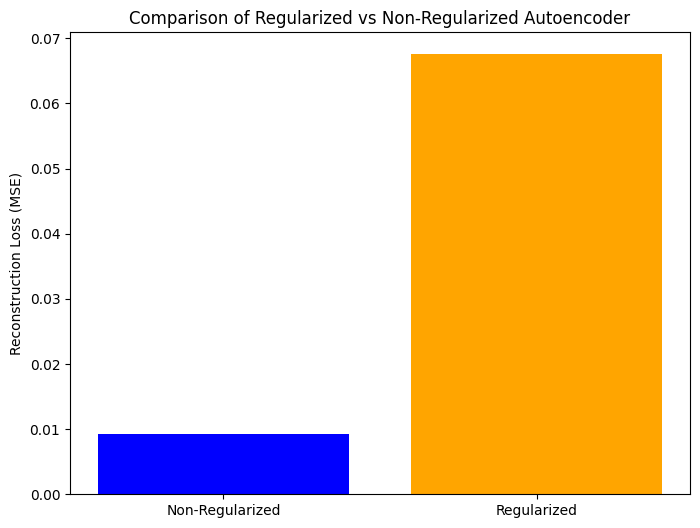

In [18]:
import matplotlib.pyplot as plt

# Plot losses
models = ['Non-Regularized', 'Regularized']
losses = [non_regularized_loss, regularized_loss]

plt.figure(figsize=(8, 6))
plt.bar(models, losses, color=['blue', 'orange'])
plt.ylabel('Reconstruction Loss (MSE)')
plt.title('Comparison of Regularized vs Non-Regularized Autoencoder')
plt.show()



1/1 [==============================] - 0s 67ms/step


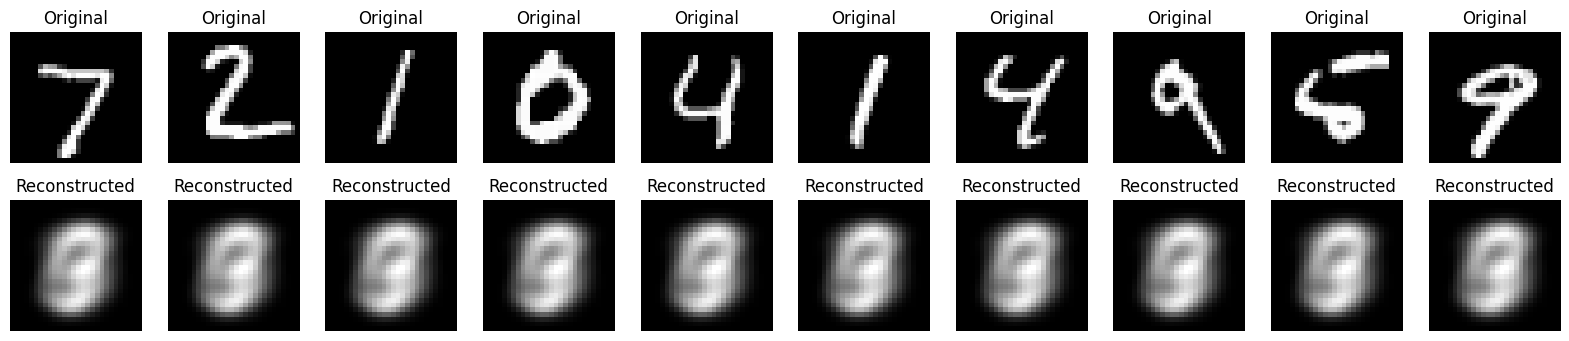

In [19]:
# Show reconstructed images
import numpy as np

def plot_reconstructed_images(model, x_test, n=10):
    decoded_imgs = model.predict(x_test[:n])
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Original images
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
        plt.title("Original")
        plt.axis('off')

        # Reconstructed images
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
        plt.title("Reconstructed")
        plt.axis('off')
    plt.show()

# Visualize reconstructed images
plot_reconstructed_images(regularized_model, x_test)

